# Sign language dataset handling
Data Analysis - ISAE-Supaero 

Project supervisor : Ahmad Berjaoui

In [114]:
import os #path handling
import numpy as np #numpy arrays operation
import matplotlib.pyplot as plt #plotting and image viewing
#import cv2 #import OpenCV for image processing 
#inline plots for nicer viewing

from sklearn.neighbors import KNeighborsClassifier #kNN classifier
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split #Data set splitting functions
from sklearn.metrics import confusion_matrix #Confusion matrix

from sklearn.metrics import accuracy_score

%matplotlib inline 

The goal of this project is to create a neural network able to determine the number hand signed in the data.

## Load input data and display

In [2]:
#dataPath = '/home/aib/Desktop/ISAE/solutions/data/signLanguage' # path to folder containing the sign language data
XFile = 'X.npy' # X
YFile = 'Y.npy' # Y

In [3]:
# Load input data and labels
X = np.load(XFile)
Y = np.load(YFile)
print(X.shape)
print(Y.shape)

(2062, 64, 64)
(2062, 10)


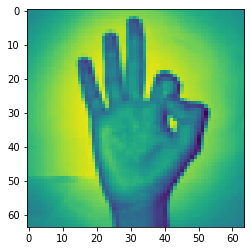

[1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


In [4]:
# Display an image and its label
imgIdx = 55
plt.imshow(X[imgIdx])
plt.show()
print(Y[imgIdx])

Let's define a function that converts the one-hot encoded labels to the corresponding sign language value, using the ClassLabels.txt mapping file

In [5]:
def labelToSignNumber(label):
  """
  Convert a one-hot encoded label to the
  corresponding sign language value.
  Mapping is given in the ClassLabels.txt
  file.
  
  Args:
    label: (numpy.array) One-hot encoded label

  Returns: (float) Sign language value
  """
  labelValue = np.argmax(label)
  mapping = {0:9,
             1:0,
             2:7,
             3:6,
             4:1,
             5:8,
             6:4,
             7:3,
             8:2,
             9:5}
  return mapping[labelValue]

Image 55 is a: 9


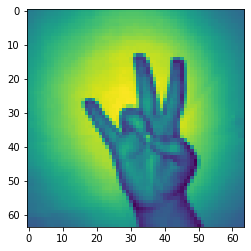

Image 600 is a: 7


In [6]:
# Let's test our function
y55 = labelToSignNumber(Y[55])
print('Image 55 is a: {}'.format(y55))
plt.imshow(X[600])
plt.show()
y600 = labelToSignNumber(Y[600])
print('Image 600 is a: {}'.format(y600))

## Filtering and features construction
Let's apply some edge detectors on an example image

In [ ]:
imgIdx = 900 #select an image index
img = X[imgIdx] #get the grayscale image matrix

sobelxImg = cv2.Sobel(img, #source image
                      cv2.CV_64F, #resulting image uses 64 bits float
                      1, #apply a Sobel filter along the X direction
                      0, #
                      ksize=5) #use a 5x5 kernel for filtering

sobelyImg = cv2.Sobel(img, #source image
                      cv2.CV_64F, #resulting image uses 64 bits float
                      0, #
                      1, #apply a Sobel filter along the Y direction
                      ksize=5) #use a 5x5 kernel for filtering

laplacianImg = cv2.Laplacian(img, #source image
                             cv2.CV_64F, #resulting image uses 64 bits float
                             ksize=5) #use a 5x5 kernel for to compute gradient magnitude

# let's display the images
def displayImg(_img,title=""):
  plt.imshow(_img)
  plt.title(title)
  plt.show()

displayImg(img,"Original Image")
displayImg(sobelxImg,"Sobel X-gradient Image")
displayImg(sobelyImg,"Sobel Y-gradient Image")
displayImg(laplacianImg,"Gradient magnitude Image")

## Features extraction and image segmentation


In [121]:
# Features extraction
def extract_features(X, N=4):
    features = np.zeros((N,N))
    eps = 0.5
    
    X = X * (X < eps)
    
    for i in range(N):
        for j in range(N):
            features[i, j] = np.sum(X[int(64/N)*i:int(64/N) * (i+1), int(64/N)*j:int(64/N)*(j+1)])
        
    return features.flatten()   


extract_features(X=np.copy(X[0]), N=4)

array([10.78823471, 16.80784416,  0.        ,  0.        , 14.21960831,
       39.06666565, 14.82745171,  0.        ,  9.96862793, 16.55294037,
       13.28235245,  0.        ,  1.48627448, 35.50980377, 40.23137665,
        0.        ])

In [125]:
# Creation of the X matrix
X_new = np.zeros((X.shape[0], 16))
X_new2 = np.zeros((X.shape[0], 64))


for i in range(X.shape[0]):
    X_new[i] = extract_features(X[i], N=4)
    X_new2[i] = extract_features(X[i], N=8)
    
X_f = np.hstack((X_new, X_new2))

print(X_f.shape)

(2062, 80)


In [127]:
# Creation of train and test sets
trainX, testX, trainY, testY = train_test_split(X_new, Y, test_size=0.2)

## kNN

In [128]:
kNN = KNeighborsClassifier(n_neighbors=12,algorithm='kd_tree',metric='minkowski',p=2,n_jobs=-1)
kNN.fit(trainX, trainY)

KNeighborsClassifier(algorithm='kd_tree', n_jobs=-1, n_neighbors=12)

In [129]:
# Check the classifier's performance on the training data
trainPredictions = kNN.predict(trainX)

trainCM = confusion_matrix(y_pred = trainPredictions.argmax(axis=1), y_true=trainY.argmax(axis=1))
print(trainCM)

[[150   0   0   0   0   1   0   0   0   8]
 [ 55 101   0   0   0   0   0   0   0   0]
 [164   0   3   0   0   0   0   0   0   0]
 [157   0   0   8   1   0   0   0   1   0]
 [129   1   0   0  44   0   0   0   1   0]
 [146   0   0   0   0  21   0   0   0   1]
 [153   0   0   0   0   1   4   0   1   0]
 [ 78   0   0   0   0   0   0  86   2   2]
 [122   0   0   0   4   0   0   1  32   0]
 [ 63   0   0   0   0   0   0   4   0 104]]


In [130]:
accuracy_score(trainY.argmax(axis=1), trainPredictions.argmax(axis=1))

0.33535476046088536

## Neural Network

In [160]:
mlp = MLPClassifier(solver='adam', alpha=1e-4, hidden_layer_sizes=(100, 20, 10), random_state=1, max_iter=10000)
mlp.fit(trainX,trainY)

MLPClassifier(hidden_layer_sizes=(100, 20, 10), max_iter=10000, random_state=1)

In [161]:
# Check the classifier's performance on the training data
trainPredictions = mlp.predict(trainX)

trainCM = confusion_matrix(y_pred = trainPredictions.argmax(axis=1), y_true=trainY.argmax(axis=1))
print(trainCM)

[[156   0   0   0   1   2   0   0   0   0]
 [  3 149   0   1   1   0   1   0   1   0]
 [ 34   1 117   5   1   1   6   0   2   0]
 [ 43   0   1 119   0   0   0   0   4   0]
 [ 13   0   1   0 160   0   0   0   1   0]
 [ 40   0   8   2   1 116   1   0   0   0]
 [ 34   0  14   8   0   0 103   0   0   0]
 [  5   0   0   0   0   0   0 159   3   1]
 [ 22   0   0   6   2   0   0   1 128   0]
 [  4   0   0   1   0   0   2   2   0 162]]


In [3]:
acc = accuracy_score(trainY.argmax(axis=1), trainPredictions.argmax(axis=1))
print("Accuracy : {}%".format(round(acc*100, 2)))

NameError: name 'accuracy_score' is not defined